<a href="https://colab.research.google.com/github/Karthikreddy1010/MicroscopicPlastic-Semantic-segmentation/blob/main/ablation_efficientnetv2b3_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ABLATION EXPERIMENT 1: EfficientNetV2-B3 Baseline (NO MRFM, NO Attention)

**Purpose:** Establish a clean baseline to evaluate the contribution of MRFM and attention mechanisms.

**Model:** Standard U-Net with EfficientNetV2-B3 encoder, simple decoder (no MRFM, no attention).

**Configuration:** Preserves all hyperparameters, losses, training strategy, and augmentation from the main model.

In [ ]:
!unzip /content/archive.zip

In [ ]:
!pip install tensorflow

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras import mixed_precision
from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from sklearn.metrics import precision_score, recall_score, f1_score
import seaborn as sns
from scipy import stats
import pandas as pd
from skimage.transform import rotate, resize
import warnings
warnings.filterwarnings('ignore')


# Confirm GPU
gpus = tf.config.list_physical_devices('GPU')
if len(gpus) > 0:
    print(" GPU detected:", gpus)
    # Enable memory growth
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

    # Enable mixed precision
    mixed_precision.set_global_policy('mixed_float16')
    print(" Mixed precision enabled")
else:
    print(" No GPU detected - running on CPU")

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Configuration - MUST MATCH ORIGINAL NOTEBOOK
IMG_HEIGHT = 512
IMG_WIDTH = 512
BATCH_SIZE = 4
EPOCHS = 100
PATIENCE = 15

# Paths to your data
TRAIN_IMAGE_DIR = '/content/training/training/Training_original'
TRAIN_MASK_DIR = '/content/training/training/Finalmasks'
VAL_IMAGE_DIR = '/content/val/val/Original'
VAL_MASK_DIR = '/content/val/val/val_100masks'
TEST_IMAGE_DIR = '/content/Testing/Testing/Original'
TEST_MASK_DIR = '/content/Testing/Testing/testing_100masks'

print(f"Configuration:")
print(f"  Image size: {IMG_HEIGHT} × {IMG_WIDTH}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {EPOCHS}")
print(f"  Patience: {PATIENCE}")

 GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
 Mixed precision enabled
Configuration:
  Image size: 512 × 512
  Batch size: 4
  Max epochs: 100
  Patience: 15


In [4]:
# ============================================================================
# DATA LOADING & PREPROCESSING (IDENTICAL TO ORIGINAL)
# ============================================================================

def normalize_name(name):
    """Normalize filename for matching."""
    name = os.path.basename(name)
    name = os.path.splitext(name)[0]
    name = name.replace('_mask', '')
    return name


def preprocess_mask(mask):
    """Proper mask binarization."""
    mask_binary = (mask > 127).astype(np.float32)
    return mask_binary


def calculate_iou(y_true, y_pred):
    """Calculate Intersection over Union for binary masks."""
    y_true = y_true.flatten().astype(np.uint8)
    y_pred = y_pred.flatten().astype(np.uint8)

    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection

    if union == 0:
        return 0.0

    return intersection / union


def calculate_miou(y_true, y_pred):
    """Calculate mean Intersection over Union for both classes."""
    y_true = y_true.flatten().astype(np.uint8)
    y_pred = y_pred.flatten().astype(np.uint8)

    iou_class_0 = calculate_iou(1 - y_true, 1 - y_pred)  # Background
    iou_class_1 = calculate_iou(y_true, y_pred)           # Foreground

    miou = (iou_class_0 + iou_class_1) / 2.0

    return {
        'iou_background': iou_class_0,
        'iou_foreground': iou_class_1,
        'miou': miou
    }


def calculate_iou_metric(y_true, y_pred):
    """
    Calculate standard IoU (Intersection over Union) metric.
    """
    y_true_flat = y_true.flatten().astype(np.uint8)
    y_pred_flat = y_pred.flatten().astype(np.uint8)

    intersection = np.sum(y_true_flat * y_pred_flat)
    union = np.sum(y_true_flat) + np.sum(y_pred_flat) - intersection

    if union == 0:
        return 1.0 if intersection == 0 else 0.0

    iou = intersection / union
    return iou


def calculate_iou_per_image(y_true, y_pred):
    """Calculate IoU for each image individually."""
    ious = []
    for i in range(len(y_true)):
        gt = y_true[i].flatten().astype(np.uint8)
        pred = y_pred[i].flatten().astype(np.uint8)

        intersection = np.sum(gt * pred)
        union = np.sum(gt) + np.sum(pred) - intersection

        if union == 0:
            iou = 1.0 if intersection == 0 else 0.0
        else:
            iou = intersection / union
        ious.append(iou)

    return np.array(ious)


def calculate_comprehensive_iou_metrics(y_true, y_pred):
    """Calculate comprehensive IoU metrics."""
    y_true_flat = y_true.flatten().astype(np.uint8)
    y_pred_flat = y_pred.flatten().astype(np.uint8)

    iou_bg = calculate_iou(1 - y_true_flat, 1 - y_pred_flat)
    iou_fg = calculate_iou(y_true_flat, y_pred_flat)
    miou = (iou_bg + iou_fg) / 2.0

    iou_standard = calculate_iou_metric(y_true, y_pred)
    per_image_ious = calculate_iou_per_image(y_true, y_pred)

    return {
        'iou': iou_standard,
        'iou_background': iou_bg,
        'iou_foreground': iou_fg,
        'miou': miou,
        'iou_mean': np.mean(per_image_ious),
        'iou_std': np.std(per_image_ious),
        'iou_median': np.median(per_image_ious),
        'iou_min': np.min(per_image_ious),
        'iou_max': np.max(per_image_ious),
        'per_image_ious': per_image_ious
    }


def calculate_segmentation_metrics(y_true, y_pred_binary):
    """Calculate pixel-wise segmentation metrics."""
    y_true_flat = y_true.flatten().astype(np.uint8)
    y_pred_flat = y_pred_binary.flatten().astype(np.uint8)

    precision = precision_score(y_true_flat, y_pred_flat, zero_division=0)
    recall = recall_score(y_true_flat, y_pred_flat, zero_division=0)
    f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)

    intersection = np.sum(y_true_flat * y_pred_flat)
    dice = (2. * intersection) / (np.sum(y_true_flat) + np.sum(y_pred_flat) + 1e-8)

    iou_metrics = calculate_comprehensive_iou_metrics(y_true, y_pred_binary)

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'dice': dice,
        'iou': iou_metrics['iou'],
        'iou_background': iou_metrics['iou_background'],
        'iou_foreground': iou_metrics['iou_foreground'],
        'miou': iou_metrics['miou'],
        'iou_mean': iou_metrics['iou_mean'],
        'iou_std': iou_metrics['iou_std'],
        'iou_median': iou_metrics['iou_median'],
        'iou_min': iou_metrics['iou_min'],
        'iou_max': iou_metrics['iou_max']
    }


print(" Utility functions defined")

 Utility functions defined


In [5]:
# ============================================================================
# AUGMENTATION PIPELINE (IDENTICAL TO ORIGINAL)
# ============================================================================

def augment_geometric_numpy(image, mask, seed=None):
    """Apply geometric augmentations (rotation, zoom, flip) with consistent randomness."""
    if hasattr(image, 'numpy'):
        image = image.numpy()
    if hasattr(mask, 'numpy'):
        mask = mask.numpy()

    image = np.asarray(image, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)

    if seed is not None:
        np.random.seed(seed)

    h, w = image.shape[:2]

    # Random rotation
    if np.random.rand() < 0.5:
        angle = np.random.uniform(-15, 15)
        image = rotate(image, angle, mode='reflect', preserve_range=True)
        mask = rotate(mask, angle, mode='reflect', preserve_range=True)

    # Random zoom
    if np.random.rand() < 0.5:
        zoom_factor = np.random.uniform(0.9, 1.1)
        new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)

        image_zoomed = resize(image, (new_h, new_w), preserve_range=True, anti_aliasing=True)
        mask_zoomed = resize(mask, (new_h, new_w), preserve_range=True, anti_aliasing=False, order=0)

        if zoom_factor > 1.0:
            start_h = (new_h - h) // 2
            start_w = (new_w - w) // 2
            image = image_zoomed[start_h:start_h+h, start_w:start_w+w]
            mask = mask_zoomed[start_h:start_h+h, start_w:start_w+w]
        else:
            pad_h = (h - new_h) // 2
            pad_w = (w - new_w) // 2

            if len(mask_zoomed.shape) == 3:
                image = np.pad(image_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                              mode='reflect')
                mask = np.pad(mask_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                             mode='constant', constant_values=0)
            else:
                image = np.pad(image_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                              mode='reflect')
                mask = np.pad(mask_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w)),
                             mode='constant', constant_values=0)

    # Random horizontal flip
    if np.random.rand() < 0.5:
        image = np.fliplr(image)
        mask = np.fliplr(mask)

    # Random vertical flip
    if np.random.rand() < 0.5:
        image = np.flipud(image)
        mask = np.flipud(mask)

    if len(mask.shape) == 2:
        mask = np.expand_dims(mask, axis=-1)

    return image.astype(np.float32), mask.astype(np.float32)


def augment_photometric_numpy(image, seed=None):
    """Apply photometric augmentations to image only."""
    if hasattr(image, 'numpy'):
        image = image.numpy()

    image = np.asarray(image, dtype=np.float32)

    if seed is not None:
        np.random.seed(seed)

    brightness = np.random.uniform(-0.05, 0.05)
    image = image + brightness

    contrast = np.random.uniform(0.95, 1.05)
    mean = image.mean()
    image = (image - mean) * contrast + mean

    gamma = np.random.uniform(0.95, 1.05)
    image = np.power(np.clip(image, 0, 1), gamma)

    noise = np.random.normal(0, 0.005, image.shape).astype(np.float32)
    image = image + noise

    image = np.clip(image, 0, 1)

    return image.astype(np.float32)


def augment_combined_numpy(image, mask):
    """Combined augmentation pipeline."""
    if hasattr(image, 'numpy'):
        image = image.numpy()
    if hasattr(mask, 'numpy'):
        mask = mask.numpy()

    image = np.asarray(image, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)

    seed = np.random.randint(0, 10000)

    image, mask = augment_geometric_numpy(image, mask, seed=seed)
    image = augment_photometric_numpy(image, seed=seed+100)

    return image, mask


print(" Augmentation functions defined")

 Augmentation functions defined


In [6]:
# ============================================================================
# DATA LOADING (IDENTICAL TO ORIGINAL)
# ============================================================================

def load_data_raw(image_dir, mask_dir):
    """Load RAW data without preprocessing - returns [0, 1] range."""
    print(f"Loading RAW data from: {image_dir}")

    if not os.path.exists(image_dir):
        raise ValueError(f"Image directory does not exist: {image_dir}")

    if not os.path.exists(mask_dir):
        raise ValueError(f"Mask directory does not exist: {mask_dir}")

    image_paths = sorted([
        os.path.join(image_dir, fname)
        for fname in os.listdir(image_dir)
        if fname.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    print(f"Found {len(image_paths)} images")

    images = []
    masks = []

    for img_idx, img_path in enumerate(image_paths):
        fname = os.path.basename(img_path)
        fname_key = normalize_name(fname)

        mask_found = False
        mask_path = None

        mask_candidate = os.path.join(mask_dir, fname_key + '_mask.png')
        if os.path.exists(mask_candidate):
            mask_path = mask_candidate
            mask_found = True

        if not mask_found:
            for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG']:
                mask_candidate = os.path.join(mask_dir, fname_key + ext)
                if os.path.exists(mask_candidate):
                    mask_path = mask_candidate
                    mask_found = True
                    break

        if not mask_found:
            base_name = os.path.splitext(fname)[0]
            for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG']:
                mask_candidate = os.path.join(mask_dir, base_name + ext)
                if os.path.exists(mask_candidate):
                    mask_path = mask_candidate
                    mask_found = True
                    break

        if not mask_found or mask_path is None:
            if img_idx < 5:
                print(f"Warning: No mask found for {fname_key}")
            continue

        try:
            img = Image.open(img_path).convert('RGB')
            img = img.resize((IMG_WIDTH, IMG_HEIGHT), Image.BILINEAR)
            img_array = np.array(img, dtype=np.float32) / 255.0

            mask = Image.open(mask_path).convert('L')
            mask = mask.resize((IMG_WIDTH, IMG_HEIGHT), Image.NEAREST)
            mask_array = np.array(mask, dtype=np.float32)
            mask_array = preprocess_mask(mask_array)
            mask_array = np.expand_dims(mask_array, axis=-1)

            images.append(img_array)
            masks.append(mask_array)

            if img_idx < 3:
                print(f"  Loaded: {fname_key} -> shape: {img_array.shape}")

        except Exception as e:
            print(f"Error loading {fname}: {e}")
            continue

    if len(images) == 0:
        raise ValueError(f"No valid images loaded from {image_dir}")

    images = np.array(images, dtype=np.float32)
    masks = np.array(masks, dtype=np.float32)

    print(f"\nSuccessfully loaded {len(images)} images")
    print(f"Image shape: {images.shape}")
    print(f"Image range: [{images.min():.4f}, {images.max():.4f}]")
    print(f"Mask shape: {masks.shape}")

    return images, masks


def create_augmented_dataset_with_preprocessing(images, masks, batch_size, augment=True, shuffle=True):
    """Create tf.data.Dataset with augmentation THEN preprocessing."""

    def preprocess_for_efficientnet(img, mask):
        img = img * 255.0
        img = preprocess_input(img)
        return img, mask

    dataset = tf.data.Dataset.from_tensor_slices((images, masks))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(images), reshuffle_each_iteration=True)

    if augment:
        def augment_fn(img, mask):
            img, mask = tf.py_function(
                func=augment_combined_numpy,
                inp=[img, mask],
                Tout=[tf.float32, tf.float32]
            )
            img.set_shape([IMG_HEIGHT, IMG_WIDTH, 3])
            mask.set_shape([IMG_HEIGHT, IMG_WIDTH, 1])
            return img, mask

        dataset = dataset.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.map(preprocess_for_efficientnet, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


print("\n" + "="*80)
print("LOADING RAW DATA (NO PREPROCESSING YET)")
print("="*80)

X_train, y_train = load_data_raw(TRAIN_IMAGE_DIR, TRAIN_MASK_DIR)
X_val, y_val = load_data_raw(VAL_IMAGE_DIR, VAL_MASK_DIR)
X_test, y_test = load_data_raw(TEST_IMAGE_DIR, TEST_MASK_DIR)

print(f"\nData shapes:")
print(f"Training:   X={X_train.shape}, y={y_train.shape}")
print(f"Validation: X={X_val.shape}, y={y_val.shape}")
print(f"Test:       X={X_test.shape}, y={y_test.shape}")

print("\n" + "="*80)
print("CREATING DATASETS WITH PREPROCESSING PIPELINE")
print("="*80)

train_dataset = create_augmented_dataset_with_preprocessing(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    augment=True,
    shuffle=True
)

val_dataset = create_augmented_dataset_with_preprocessing(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    augment=False,
    shuffle=False
)

test_dataset = create_augmented_dataset_with_preprocessing(
    X_test, y_test,
    batch_size=BATCH_SIZE,
    augment=False,
    shuffle=False
)

print(" Datasets created successfully:")
print(f"   Training:   {len(X_train)} samples (augment → preprocess)")
print(f"   Validation: {len(X_val)} samples (preprocess only)")
print(f"   Test:       {len(X_test)} samples (preprocess only)")

print("\n Verifying preprocessing pipeline:")
for img_batch, mask_batch in train_dataset.take(1):
    print(f"   Batch shape: {img_batch.shape}")
    print(f"   After preprocessing: range=[{img_batch.numpy().min():.4f}, {img_batch.numpy().max():.4f}]")
    print(f"   Mean: {img_batch.numpy().mean():.4f}")
    break

print("="*80)


LOADING RAW DATA (NO PREPROCESSING YET)
Loading RAW data from: /content/training/training/Training_original
Found 556 images
  Loaded: 100_jpg.rf.f1b9d16649ab385e3691fa54301a3b61 -> shape: (512, 512, 3)
  Loaded: 106_jpg.rf.e8dc04354de3fadaea50922857adf45e -> shape: (512, 512, 3)
  Loaded: 10_jpg.rf.ecfa6fcdfec86c013936528ac959e40d -> shape: (512, 512, 3)

Successfully loaded 556 images
Image shape: (556, 512, 512, 3)
Image range: [0.0000, 1.0000]
Mask shape: (556, 512, 512, 1)
Loading RAW data from: /content/val/val/Original
Found 208 images
  Loaded: a--47-_jpg.rf.4b52f93a6fb94ded6e3a16355ccdf382 -> shape: (512, 512, 3)
  Loaded: a--54-_jpg.rf.0383febe7b193195524f26c0df25ea8c -> shape: (512, 512, 3)
  Loaded: a--56-_jpg.rf.b47891c3c1b3bdf692a27eed2ed119ab -> shape: (512, 512, 3)

Successfully loaded 100 images
Image shape: (100, 512, 512, 3)
Image range: [0.0000, 1.0000]
Mask shape: (100, 512, 512, 1)
Loading RAW data from: /content/Testing/Testing/Original
Found 200 images
  Loaded

In [7]:
# ============================================================================
# MODEL ARCHITECTURE: BASELINE U-NET WITHOUT MRFM AND WITHOUT ATTENTION
# ============================================================================

def build_efficientnetv2b3_baseline_unet(input_shape=(512, 512, 3)):
    """
    Build EfficientNetV2B3-based U-Net WITHOUT MRFM and WITHOUT attention.
    This is the clean baseline for ablation.
    Output shape: (batch_size, 512, 512, 1)
    """
    inputs = layers.Input(shape=input_shape, name='input_image')

    # Backbone encoder (trainable)
    backbone = EfficientNetV2B3(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )
    backbone.trainable = True

    print(f" Backbone trainable: {backbone.trainable}")
    print(f" Total backbone layers: {len(backbone.layers)}")

    # Extract encoder features
    try:
        e1 = backbone.get_layer('block1b_add').output      # ~256x256
        e2 = backbone.get_layer('block2b_add').output      # ~128x128
        e3 = backbone.get_layer('block3b_add').output      # ~64x64
        e4 = backbone.get_layer('block5c_add').output      # ~32x32
        e5 = backbone.get_layer('top_activation').output   # ~16x16
        print(" Successfully extracted all encoder features")
    except Exception as e:
        print(f" Error extracting encoder features: {e}")
        print("Available layer names:")
        for layer in backbone.layers:
            if 'block' in layer.name or 'top' in layer.name:
                print(f"  - {layer.name}: {layer.output_shape}")
        raise

    # Get actual channel counts
    e1_channels = K.int_shape(e1)[-1]
    e2_channels = K.int_shape(e2)[-1]
    e3_channels = K.int_shape(e3)[-1]
    e4_channels = K.int_shape(e4)[-1]
    e5_channels = K.int_shape(e5)[-1]

    print(f"\n Encoder feature channels:")
    print(f"  e1: {e1_channels}, e2: {e2_channels}, e3: {e3_channels}, e4: {e4_channels}, e5: {e5_channels}")

    # ========================================================================
    # DECODER - SIMPLE CONVOLUTION BLOCKS (NO MRFM, NO ATTENTION)
    # ========================================================================

    # Decoder block: 2 conv layers
    def decoder_block(x, skip, num_filters, name):
        # Upsample
        x = layers.Conv2DTranspose(num_filters, 2, strides=2, padding='same',
                                   kernel_initializer='he_normal',
                                   name=f'{name}_up')(x)
        # Concatenate with skip
        x = layers.Concatenate(name=f'{name}_concat')([x, skip])
        # Two conv blocks
        x = layers.Conv2D(num_filters, 3, padding='same', activation='relu',
                         kernel_initializer='he_normal',
                         name=f'{name}_conv1')(x)
        x = layers.BatchNormalization(name=f'{name}_bn1')(x)
        x = layers.Conv2D(num_filters, 3, padding='same', activation='relu',
                         kernel_initializer='he_normal',
                         name=f'{name}_conv2')(x)
        x = layers.BatchNormalization(name=f'{name}_bn2')(x)
        return x

    # Decoder path
    d4 = decoder_block(e5, e4, 256, 'dec4')
    d3 = decoder_block(d4, e3, 128, 'dec3')
    d2 = decoder_block(d3, e2, 64, 'dec2')
    d1 = decoder_block(d2, e1, 32, 'dec1')

    # Final upsampling to 512x512
    d0 = layers.Conv2DTranspose(16, 2, strides=2, padding='same',
                                kernel_initializer='he_normal',
                                name='up0')(d1)
    d0 = layers.Conv2D(32, 3, padding='same', activation='relu',
                       kernel_initializer='he_normal',
                       name='final_conv1')(d0)
    d0 = layers.Conv2D(16, 3, padding='same', activation='relu',
                       kernel_initializer='he_normal',
                       name='final_conv2')(d0)

    # Output layer
    outputs = layers.Conv2D(
        1, 1, activation='sigmoid',
        dtype='float32',
        kernel_initializer='glorot_uniform',
        name='segmentation_output'
    )(d0)

    # Create model
    model = models.Model(
        inputs, outputs,
        name='EfficientNetV2B3_Baseline_UNet'
    )

    print(f"\n Model created successfully!")
    print(f"   Input shape:  {model.input_shape}")
    print(f"   Output shape: {model.output_shape}")
    print(f"   Total params: {model.count_params():,}")
    print(f"   Trainable params: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")

    return model, backbone


print("\n" + "="*80)
print("BUILDING BASELINE MODEL (NO MRFM, NO ATTENTION)")
print("="*80)

model, backbone = build_efficientnetv2b3_baseline_unet(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

print(f"\n Model built successfully")


BUILDING BASELINE MODEL (NO MRFM, NO ATTENTION)
52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
 Backbone trainable: True
 Total backbone layers: 409
 Successfully extracted all encoder features

 Encoder feature channels:
  e1: 16, e2: 40, e3: 56, e4: 136, e5: 1536

 Model created successfully!
   Input shape:  (None, 512, 512, 3)
   Output shape: (None, 512, 512, 1)
   Total params: 16,664,367
   Trainable params: 16,553,231

 Model built successfully


In [8]:
# ============================================================================
# LOSS FUNCTIONS (IDENTICAL TO ORIGINAL)
# ============================================================================

from sklearn.utils.class_weight import compute_class_weight

def calculate_class_weights(masks):
    """Calculate class weights for imbalanced segmentation."""
    masks_flat = (masks > 0.5).astype(np.uint8).flatten()
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.array([0, 1]),
        y=masks_flat
    )
    return {0: class_weights[0], 1: class_weights[1]}


if len(y_train) > 0:
    class_weights = calculate_class_weights(y_train)
    cw0 = tf.constant(class_weights[0], dtype=tf.float32)
    cw1 = tf.constant(class_weights[1], dtype=tf.float32)
    print(f"Class weights - Background: {cw0:.4f}, Foreground: {cw1:.4f}")
else:
    cw0 = tf.constant(1.0, dtype=tf.float32)
    cw1 = tf.constant(1.0, dtype=tf.float32)
    print(" No training data - using default weights")


def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Dice coefficient metric."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_flat * y_pred_flat)
    union = tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat)
    return (2.0 * intersection + smooth) / (union + smooth)


def dice_loss(y_true, y_pred, smooth=1e-6):
    """Dice loss."""
    return 1.0 - dice_coefficient(y_true, y_pred, smooth)


def focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0):
    """Focal loss for class imbalance."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])
    y_pred_flat = tf.clip_by_value(y_pred_flat, K.epsilon(), 1 - K.epsilon())

    pt = tf.where(tf.equal(y_true_flat, 1), y_pred_flat, 1 - y_pred_flat)
    alpha_t = tf.where(tf.equal(y_true_flat, 1), alpha, 1 - alpha)
    loss = -alpha_t * tf.pow(1 - pt, gamma) * tf.math.log(pt)
    return tf.reduce_mean(loss)


def tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, smooth=1e-6):
    """Tversky loss - emphasizes recall."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])

    true_pos = tf.reduce_sum(y_true_flat * y_pred_flat)
    false_neg = tf.reduce_sum(y_true_flat * (1 - y_pred_flat))
    false_pos = tf.reduce_sum((1 - y_true_flat) * y_pred_flat)

    tversky = (true_pos + smooth) / (true_pos + alpha * false_neg + beta * false_pos + smooth)
    return 1.0 - tversky


def aggressive_imbalance_loss(y_true, y_pred):
    """Combined loss for severe class imbalance."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1 - K.epsilon())

    dice = dice_loss(y_true, y_pred)
    tversky = tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3)
    focal = focal_loss(y_true, y_pred, alpha=0.75, gamma=2.0)

    total_loss = 5.0 * dice + 3.0 * tversky + 1.0 * focal
    return total_loss


def focal_dice_loss(y_true, y_pred, gamma=2.0, dice_weight=3.0, focal_weight=1.0):
    """Combined focal and dice loss."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    focal = focal_loss(y_true, y_pred, alpha=0.75, gamma=gamma)
    dice = dice_loss(y_true, y_pred)
    return focal_weight * focal + dice_weight * dice


def iou_metric(y_true, y_pred, smooth=1e-6):
    """IoU metric."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_flat * y_pred_flat)
    union = tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou


def dice_numpy(y_true, y_pred, smooth=1e-6):
    """Dice coefficient for numpy arrays."""
    y_true = y_true.astype(np.float32).flatten()
    y_pred = y_pred.astype(np.float32).flatten()
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)


print(" Loss functions defined")

Class weights - Background: 0.5228, Foreground: 11.4485
 Loss functions defined


In [9]:
# ============================================================================
# TRAINING CALLBACKS
# ============================================================================

class PredictionMonitor(tf.keras.callbacks.Callback):
    """Monitor predictions during training."""
    def __init__(self, val_data, val_masks):
        super().__init__()
        self.val_data_raw = val_data[:4]
        self.val_masks = val_masks[:4]
        self.val_data = preprocess_input(self.val_data_raw * 255.0)

    def on_epoch_end(self, epoch, logs=None):
        if epoch % 3 == 0:
            preds = self.model.predict(self.val_data, verbose=0)
            preds_flat = preds.flatten()
            fg_pixels = (preds_flat > 0.5).sum()
            total_pixels = preds_flat.size
            max_pred = preds_flat.max()
            mean_pred = preds_flat.mean()
            print(f"\n   [Epoch {epoch}] Predictions: max={max_pred:.4f}, mean={mean_pred:.4f}, "
                  f"fg_pixels={fg_pixels:,}/{total_pixels:,} ({fg_pixels/total_pixels*100:.3f}%)")


print(" Callbacks defined")

 Callbacks defined


In [10]:
# ============================================================================
# PHASE 1: TRAINING DECODER (BACKBONE FROZEN)
# ============================================================================

print("\n" + "="*80)
print("PHASE 1: Training decoder (backbone frozen)")
print("="*80)

backbone.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=aggressive_imbalance_loss,
    metrics=[dice_coefficient, iou_metric]
)

callbacks_phase1 = [
    PredictionMonitor(X_val, y_val),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coefficient',
        patience=15,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_dice_coefficient',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/efficientnetv2b3_baseline_phase1.weights.h5',
        monitor='val_dice_coefficient',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    )
]

print(f"\nTraining Phase 1 with {len(X_train)} samples")
history_phase1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=40,
    callbacks=callbacks_phase1,
    verbose=1
)

best_dice_phase1 = max(history_phase1.history['val_dice_coefficient'])
print(f"\n Phase 1 complete - Best Dice: {best_dice_phase1:.4f}")


PHASE 1: Training decoder (backbone frozen)

Training Phase 1 with 556 samples
Epoch 1/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - dice_coefficient: 0.4333 - iou_metric: 0.3058 - loss: 4.5214
   [Epoch 0] Predictions: max=1.0000, mean=0.0645, fg_pixels=60,414/1,048,576 (5.762%)

Epoch 1: val_dice_coefficient improved from None to 0.37919, saving model to /content/efficientnetv2b3_baseline_phase1.weights.h5

Epoch 1: finished saving model to /content/efficientnetv2b3_baseline_phase1.weights.h5
139/139 ━━━━━━━━━━━━━━━━━━━━ 168s 416ms/step - dice_coefficient: 0.5821 - iou_metric: 0.4322 - loss: 3.3704 - val_dice_coefficient: 0.3792 - val_iou_metric: 0.2523 - val_loss: 4.7342 - learning_rate: 0.0010
Epoch 2/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - dice_coefficient: 0.6910 - iou_metric: 0.5340 - loss: 2.5092
Epoch 2: val_dice_coefficient improved from 0.37919 to 0.67140, saving model to /content/efficientnetv2b3_baseline_phase1.weights.h5

Epoch 2: finished saving model to /cont

In [11]:
# ============================================================================
# PHASE 2: FINE-TUNING ENTIRE MODEL
# ============================================================================

print("\n" + "="*80)
print("PHASE 2: Fine-tuning entire model")
print("="*80)

backbone.trainable = True
for layer in backbone.layers[:-80]:
    layer.trainable = False

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

optimizer_ft = tf.keras.optimizers.AdamW(
    learning_rate=5e-5,
    weight_decay=1e-5,
    beta_1=0.9,
    beta_2=0.999
)

model.compile(
    optimizer=optimizer_ft,
    loss=focal_dice_loss,
    metrics=[
        dice_coefficient,
        iou_metric,
        'binary_accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks_phase2 = [
    PredictionMonitor(X_val, y_val),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coefficient',
        patience=PATIENCE,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_dice_coefficient',
        factor=0.5,
        patience=8,
        min_lr=1e-7,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/efficientnetv2b3_baseline_final.weights.h5',
        monitor='val_dice_coefficient',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    )
]

print(f"\nTraining Phase 2 with {len(X_train)} samples")
history_phase2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks_phase2,
    verbose=1,
    initial_epoch=len(history_phase1.history['loss'])
)

best_dice_phase2 = max(history_phase2.history['val_dice_coefficient'])
best_iou_phase2 = max(history_phase2.history['val_iou_metric'])
epochs_completed = len(history_phase1.history['loss']) + len(history_phase2.history['loss'])

print("\n Two-phase training complete!")
print(f"   Best Dice (Phase 2): {best_dice_phase2:.4f}")
print(f"   Best IoU (Phase 2): {best_iou_phase2:.4f}")
print(f"   Total epochs: {epochs_completed}")

print("\n" + "="*80)
print("TRAINING COMPLETE - MODEL READY FOR EVALUATION")
print("="*80)


PHASE 2: Fine-tuning entire model

Training Phase 2 with 556 samples
Epoch 41/100
138/139 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - binary_accuracy: 0.9787 - dice_coefficient: 0.7655 - iou_metric: 0.6262 - loss: 0.7548 - precision: 0.7882 - recall: 0.7725
Epoch 41: val_dice_coefficient improved from None to 0.72849, saving model to /content/efficientnetv2b3_baseline_final.weights.h5

Epoch 41: finished saving model to /content/efficientnetv2b3_baseline_final.weights.h5
139/139 ━━━━━━━━━━━━━━━━━━━━ 114s 273ms/step - binary_accuracy: 0.9802 - dice_coefficient: 0.7776 - iou_metric: 0.6428 - loss: 0.7131 - precision: 0.7958 - recall: 0.7871 - val_binary_accuracy: 0.9923 - val_dice_coefficient: 0.7285 - val_iou_metric: 0.5840 - val_loss: 0.8375 - val_precision: 0.7946 - val_recall: 0.8395 - learning_rate: 5.0000e-05
Epoch 42/100
138/139 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - binary_accuracy: 0.9809 - dice_coefficient: 0.7785 - iou_metric: 0.6442 - loss: 0.7083 - precision: 0.8012 - recall: 0.7836

In [12]:
# ============================================================================
# LOAD BEST MODEL
# ============================================================================

print("\n" + "="*80)
print("LOADING BEST MODEL")
print("="*80)

model, backbone = build_efficientnetv2b3_baseline_unet(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

backbone.trainable = True
for layer in backbone.layers[:-80]:
    layer.trainable = False

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

optimizer_ft = tf.keras.optimizers.AdamW(
    learning_rate=5e-5,
    weight_decay=1e-5,
    beta_1=0.9,
    beta_2=0.999
)

model.compile(
    optimizer=optimizer_ft,
    loss=focal_dice_loss,
    metrics=[
        dice_coefficient,
        iou_metric,
        'binary_accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("Loading best weights...")
model.load_weights('/content/efficientnetv2b3_baseline_final.weights.h5')
print(" Model weights loaded successfully")

# Store model info
model_total_params = model.count_params()
model_trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])

print(f"\n Model Summary:")
print(f"   Total parameters: {model_total_params:,}")
print(f"   Trainable parameters: {model_trainable_params:,}")


LOADING BEST MODEL
 Backbone trainable: True
 Total backbone layers: 409
 Successfully extracted all encoder features

 Encoder feature channels:
  e1: 16, e2: 40, e3: 56, e4: 136, e5: 1536

 Model created successfully!
   Input shape:  (None, 512, 512, 3)
   Output shape: (None, 512, 512, 1)
   Total params: 16,664,367
   Trainable params: 16,553,231
Loading best weights...
 Model weights loaded successfully

 Model Summary:
   Total parameters: 16,664,367
   Trainable parameters: 8,192,947


In [13]:
# ============================================================================
# THRESHOLD TUNING ON VALIDATION SET
# ============================================================================

print("\n" + "="*80)
print(" TUNING SEGMENTATION THRESHOLD ON VALIDATION SET")
print("="*80)

def preprocess_test_data(X_test):
    """Preprocess test data the same way as training data."""
    X_test_preprocessed = preprocess_input(X_test * 255.0)
    return X_test_preprocessed


X_val_preprocessed = preprocess_test_data(X_val)

print("Generating raw validation predictions...")
y_val_pred_soft = model.predict(
    X_val_preprocessed,
    batch_size=BATCH_SIZE,
    verbose=1
)

# Tune threshold
thresholds = np.linspace(0.1, 0.7, 13)
best_t, best_dice = 0, 0

print("\nThreshold tuning results:")
print("-" * 40)

for t in thresholds:
    y_val_pred_bin = (y_val_pred_soft > t).astype(np.uint8)
    dice = dice_numpy(y_val, y_val_pred_bin)

    print(f"  Threshold={t:.2f} → Dice={dice:.4f}")

    if dice > best_dice:
        best_dice = dice
        best_t = t

print("-" * 40)
print(f" Best threshold: {best_t:.2f}")
print(f" Best Dice on validation: {best_dice:.4f}")

SEG_THRESHOLD = best_t
print(f" Locked threshold at {SEG_THRESHOLD:.2f}")
print("="*80)


 TUNING SEGMENTATION THRESHOLD ON VALIDATION SET
Generating raw validation predictions...
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step

Threshold tuning results:
----------------------------------------
  Threshold=0.10 → Dice=0.8131
  Threshold=0.15 → Dice=0.8150
  Threshold=0.20 → Dice=0.8161
  Threshold=0.25 → Dice=0.8170
  Threshold=0.30 → Dice=0.8176
  Threshold=0.35 → Dice=0.8183
  Threshold=0.40 → Dice=0.8188
  Threshold=0.45 → Dice=0.8193
  Threshold=0.50 → Dice=0.8197
  Threshold=0.55 → Dice=0.8202
  Threshold=0.60 → Dice=0.8206
  Threshold=0.65 → Dice=0.8211
  Threshold=0.70 → Dice=0.8216
----------------------------------------
 Best threshold: 0.70
 Best Dice on validation: 0.8216
 Locked threshold at 0.70


In [14]:
# ============================================================================
# TRAINING SET EVALUATION
# ============================================================================

print("\n" + "="*80)
print(" EVALUATING TRAINING SET")
print("="*80)

X_train_preprocessed = preprocess_test_data(X_train)

print(f"\n Generating training set predictions...")
y_train_pred_soft = model.predict(
    X_train_preprocessed,
    batch_size=BATCH_SIZE,
    verbose=1
)

y_train_pred_binary = (y_train_pred_soft > SEG_THRESHOLD).astype(np.uint8)
y_train_binary = (y_train > 0.5).astype(np.uint8)

train_metrics = calculate_segmentation_metrics(y_train_binary, y_train_pred_binary)

print(f"\n{'='*60}")
print(f"TRAINING SET RESULTS (Threshold={SEG_THRESHOLD:.2f})")
print(f"{'='*60}")
print(f"{'Metric':<25} {'Value':<10}")
print(f"{'-'*60}")
print(f"{'Dice Coefficient':<25} {train_metrics['dice']:.4f}")
print(f"{'Precision':<25} {train_metrics['precision']:.4f}")
print(f"{'Recall':<25} {train_metrics['recall']:.4f}")
print(f"{'mIoU':<25} {train_metrics['miou']:.4f}")
print(f"{'IoU (Foreground)':<25} {train_metrics['iou_foreground']:.4f}")
print(f"{'IoU (Background)':<25} {train_metrics['iou_background']:.4f}")
print(f"{'='*60}")


 EVALUATING TRAINING SET

 Generating training set predictions...
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step

TRAINING SET RESULTS (Threshold=0.70)
Metric                    Value     
------------------------------------------------------------
Dice Coefficient          0.8029
Precision                 0.8317
Recall                    0.7760
mIoU                      0.8267
IoU (Foreground)          0.6707
IoU (Background)          0.9828


In [15]:
# ============================================================================
# TEST SET EVALUATION
# ============================================================================

print("\n" + "="*80)
print(" EVALUATING TEST SET")
print("="*80)

X_test_preprocessed = preprocess_test_data(X_test)

print(f"\n Generating test set predictions...")
y_test_pred_soft = model.predict(
    X_test_preprocessed,
    batch_size=BATCH_SIZE,
    verbose=1
)

y_test_pred_binary = (y_test_pred_soft > SEG_THRESHOLD).astype(np.uint8)
y_test_binary = (y_test > 0.5).astype(np.uint8)

test_metrics = calculate_segmentation_metrics(y_test_binary, y_test_pred_binary)

print(f"\n{'='*60}")
print(f"TEST SET RESULTS (Threshold={SEG_THRESHOLD:.2f})")
print(f"{'='*60}")
print(f"{'Metric':<25} {'Value':<10}")
print(f"{'-'*60}")
print(f"{'Dice Coefficient':<25} {test_metrics['dice']:.4f}")
print(f"{'Precision':<25} {test_metrics['precision']:.4f}")
print(f"{'Recall':<25} {test_metrics['recall']:.4f}")
print(f"{'mIoU':<25} {test_metrics['miou']:.4f}")
print(f"{'IoU (Foreground)':<25} {test_metrics['iou_foreground']:.4f}")
print(f"{'IoU (Background)':<25} {test_metrics['iou_background']:.4f}")
print(f"{'='*60}")


 EVALUATING TEST SET

 Generating test set predictions...
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

TEST SET RESULTS (Threshold=0.70)
Metric                    Value     
------------------------------------------------------------
Dice Coefficient          0.7858
Precision                 0.7594
Recall                    0.8140
mIoU                      0.8195
IoU (Foreground)          0.6471
IoU (Background)          0.9919


In [16]:
# ============================================================================
# CREATE RESULTS DATAFRAME
# ============================================================================

print("\n" + "="*80)
print(" CREATING RESULTS SUMMARY")
print("="*80)

results_data = {
    'Model': ['EfficientNetV2-B3 Baseline', 'EfficientNetV2-B3 Baseline'],
    'Dataset': ['Train', 'Test'],
    'Dice': [train_metrics['dice'], test_metrics['dice']],
    'Foreground IoU': [train_metrics['iou_foreground'], test_metrics['iou_foreground']],
    'Background IoU': [train_metrics['iou_background'], test_metrics['iou_background']],
    'mIoU': [train_metrics['miou'], test_metrics['miou']],
    'Precision': [train_metrics['precision'], test_metrics['precision']],
    'Recall': [train_metrics['recall'], test_metrics['recall']]
}

results_df = pd.DataFrame(results_data)

print("\n" + results_df.to_string(index=False))
print("\n")

# Save to CSV
os.makedirs('results_efficientnetv2b3_baseline', exist_ok=True)
results_df.to_csv('results_efficientnetv2b3_baseline/results.csv', index=False)
print(" Results saved to CSV")


 CREATING RESULTS SUMMARY

                     Model Dataset     Dice  Foreground IoU  Background IoU     mIoU  Precision   Recall
EfficientNetV2-B3 Baseline   Train 0.802870        0.670662        0.982774 0.826718   0.831716 0.775957
EfficientNetV2-B3 Baseline    Test 0.785754        0.647112        0.991925 0.819519   0.759414 0.813985


 Results saved to CSV



 CREATING TRAINING HISTORY PLOTS


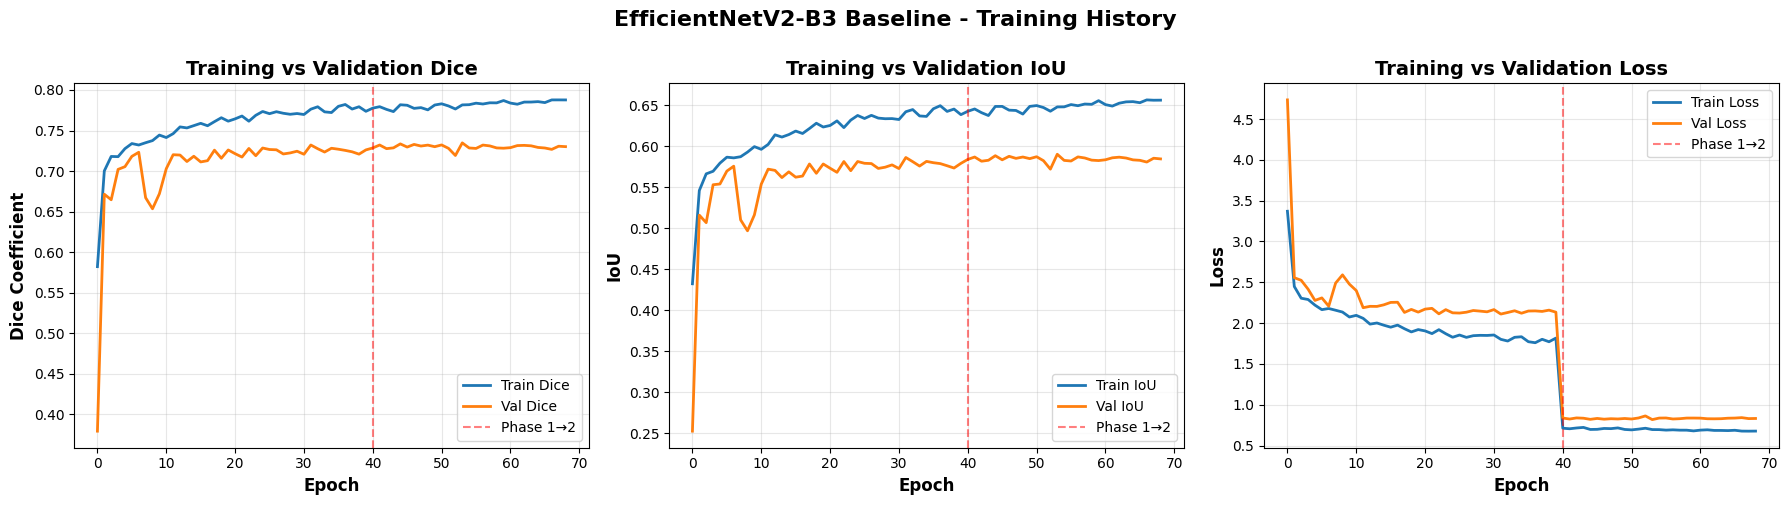

 Training history plots saved


In [17]:
# ============================================================================
# TRAINING HISTORY PLOTS
# ============================================================================

print("\n" + "="*80)
print(" CREATING TRAINING HISTORY PLOTS")
print("="*80)

# Combine histories
combined_history = {
    'loss': history_phase1.history['loss'] + history_phase2.history['loss'],
    'val_loss': history_phase1.history['val_loss'] + history_phase2.history['val_loss'],
    'dice_coefficient': history_phase1.history['dice_coefficient'] + history_phase2.history['dice_coefficient'],
    'val_dice_coefficient': history_phase1.history['val_dice_coefficient'] + history_phase2.history['val_dice_coefficient'],
    'iou_metric': history_phase1.history['iou_metric'] + history_phase2.history['iou_metric'],
    'val_iou_metric': history_phase1.history['val_iou_metric'] + history_phase2.history['val_iou_metric']
}

# Plot 1: Loss
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Dice curve
axes[0].plot(combined_history['dice_coefficient'], label='Train Dice', linewidth=2)
axes[0].plot(combined_history['val_dice_coefficient'], label='Val Dice', linewidth=2)
axes[0].axvline(len(history_phase1.history['loss']), color='red', linestyle='--', alpha=0.5, label='Phase 1→2')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Dice Coefficient', fontsize=12, fontweight='bold')
axes[0].set_title('Training vs Validation Dice', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# IoU curve
axes[1].plot(combined_history['iou_metric'], label='Train IoU', linewidth=2)
axes[1].plot(combined_history['val_iou_metric'], label='Val IoU', linewidth=2)
axes[1].axvline(len(history_phase1.history['loss']), color='red', linestyle='--', alpha=0.5, label='Phase 1→2')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('IoU', fontsize=12, fontweight='bold')
axes[1].set_title('Training vs Validation IoU', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Loss curve
axes[2].plot(combined_history['loss'], label='Train Loss', linewidth=2)
axes[2].plot(combined_history['val_loss'], label='Val Loss', linewidth=2)
axes[2].axvline(len(history_phase1.history['loss']), color='red', linestyle='--', alpha=0.5, label='Phase 1→2')
axes[2].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[2].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.suptitle('EfficientNetV2-B3 Baseline - Training History', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('results_efficientnetv2b3_baseline/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Training history plots saved")


 CREATING SAMPLE PREDICTION VISUALIZATIONS


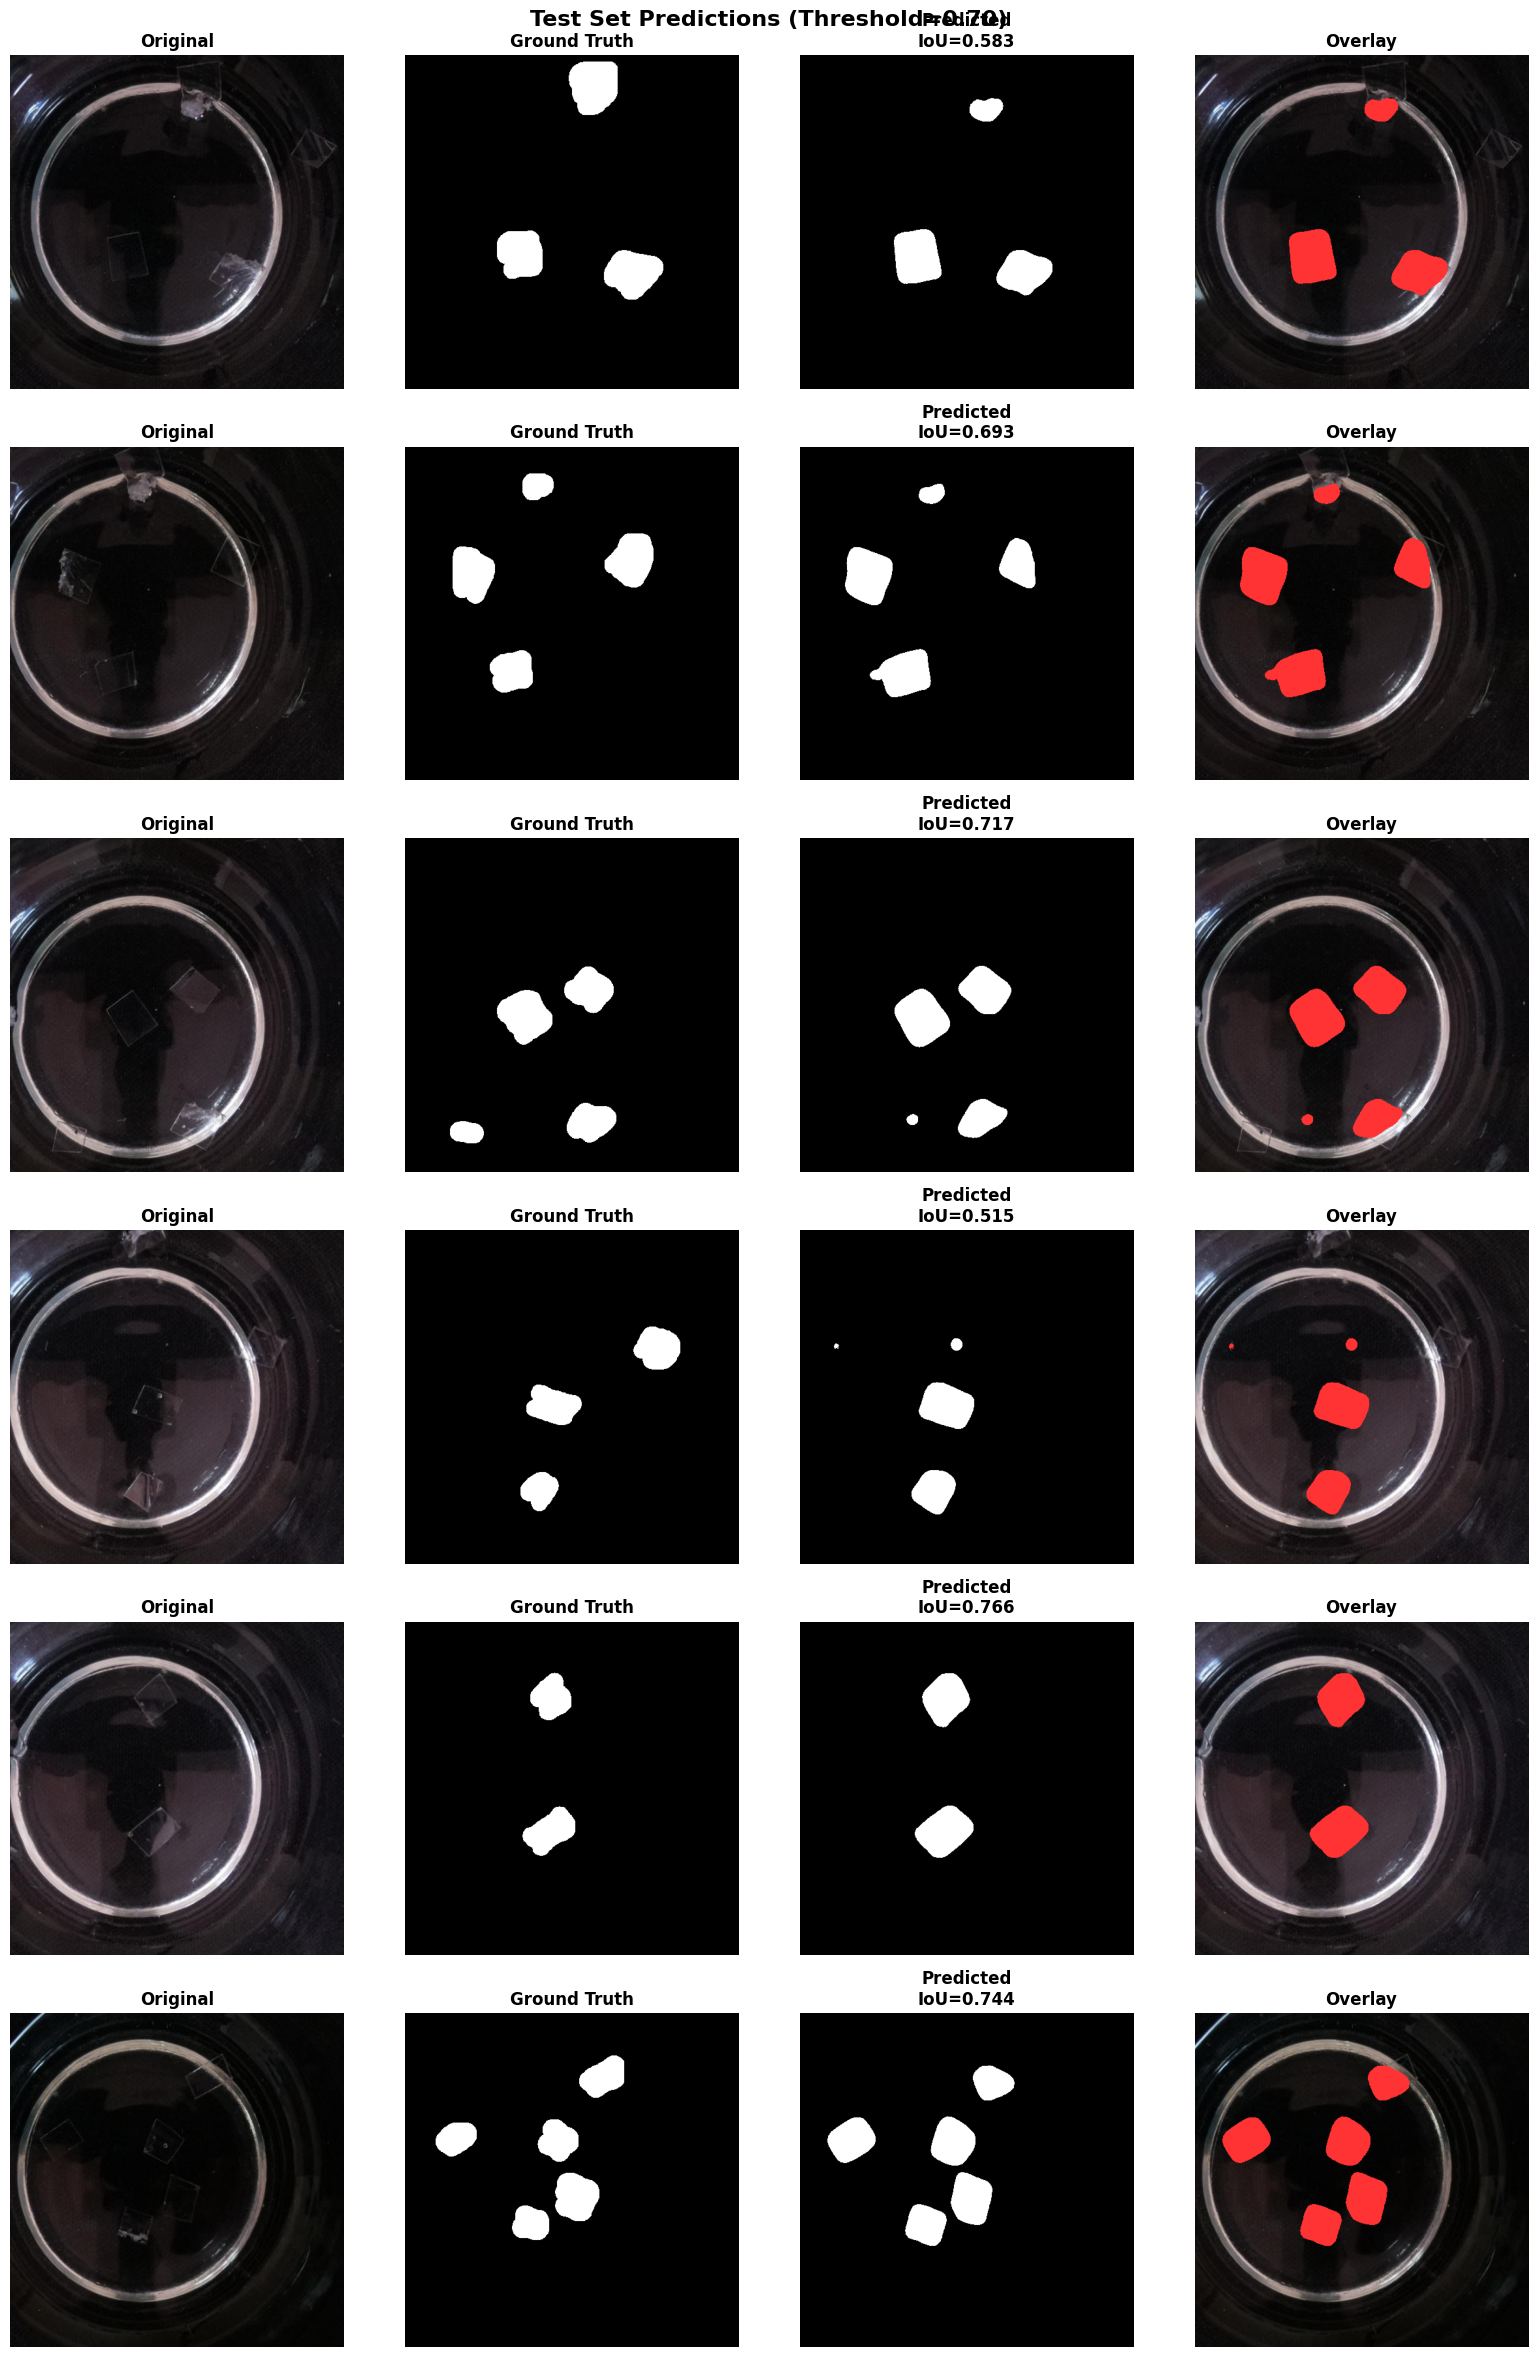

 Sample predictions visualization saved


In [18]:
# ============================================================================
# VISUALIZATION: SAMPLE PREDICTIONS
# ============================================================================

print("\n" + "="*80)
print(" CREATING SAMPLE PREDICTION VISUALIZATIONS")
print("="*80)

num_samples = min(6, len(X_test))
fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
if num_samples == 1:
    axes = axes.reshape(1, -1)

for idx in range(num_samples):
    img_display = np.clip(X_test[idx], 0, 1)
    gt_mask = y_test_binary[idx].squeeze()
    pred_mask = y_test_pred_binary[idx].squeeze()

    axes[idx, 0].imshow(img_display)
    axes[idx, 0].set_title('Original', fontweight='bold')
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(gt_mask, cmap='gray')
    axes[idx, 1].set_title('Ground Truth', fontweight='bold')
    axes[idx, 1].axis('off')

    iou = calculate_iou(gt_mask.flatten(), pred_mask.flatten())
    axes[idx, 2].imshow(pred_mask, cmap='gray')
    axes[idx, 2].set_title(f'Predicted\nIoU={iou:.3f}', fontweight='bold')
    axes[idx, 2].axis('off')

    overlay = img_display.copy()
    if len(overlay.shape) == 2:
        overlay = np.stack([overlay]*3, axis=-1)
    overlay[pred_mask > 0.5] = [1.0, 0.2, 0.2]
    axes[idx, 3].imshow(overlay)
    axes[idx, 3].set_title('Overlay', fontweight='bold')
    axes[idx, 3].axis('off')

plt.suptitle(f'Test Set Predictions (Threshold={SEG_THRESHOLD:.2f})',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('results_efficientnetv2b3_baseline/test_predictions.png',
            dpi=300, bbox_inches='tight')
plt.show()

print(" Sample predictions visualization saved")


 CREATING PERFORMANCE SUMMARY PLOTS


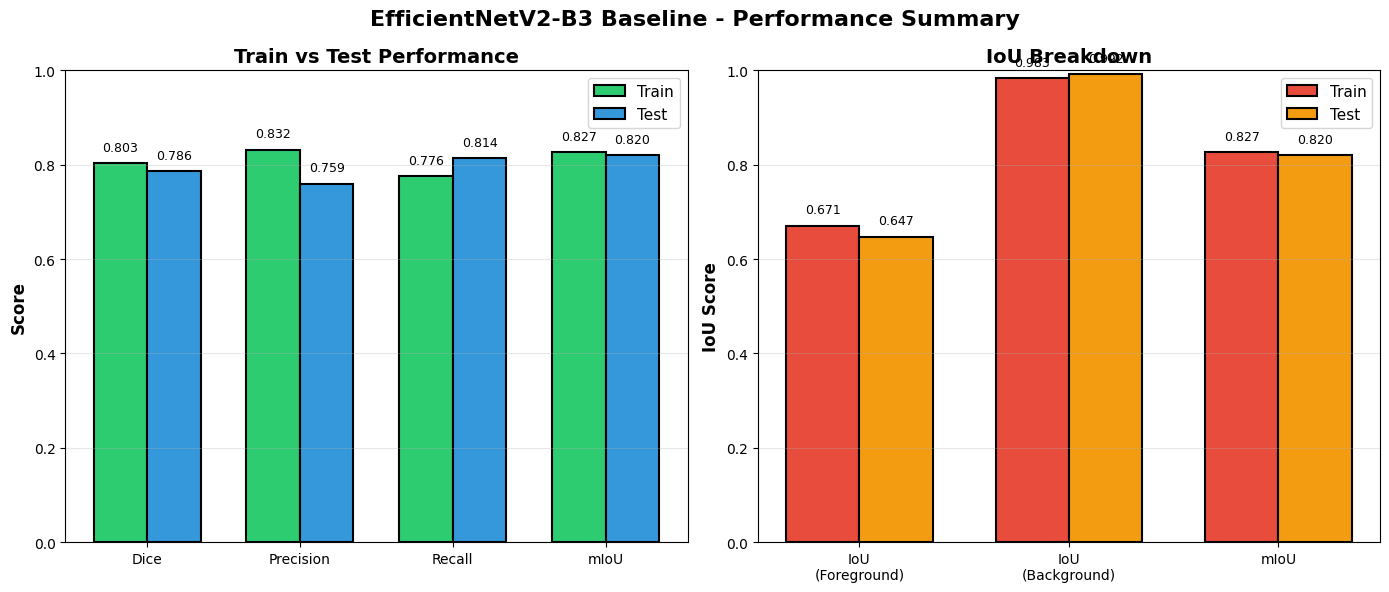

 Performance summary plot saved


In [19]:
# ============================================================================
# PERFORMANCE SUMMARY PLOTS
# ============================================================================

print("\n" + "="*80)
print(" CREATING PERFORMANCE SUMMARY PLOTS")
print("="*80)

fig = plt.figure(figsize=(14, 6))

# Metrics bar chart
ax1 = plt.subplot(1, 2, 1)
metrics_names = ['Dice', 'Precision', 'Recall', 'mIoU']
train_values = [train_metrics['dice'], train_metrics['precision'],
                train_metrics['recall'], train_metrics['miou']]
test_values = [test_metrics['dice'], test_metrics['precision'],
               test_metrics['recall'], test_metrics['miou']]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax1.bar(x - width/2, train_values, width, label='Train', color='#2ecc71', edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, test_values, width, label='Test', color='#3498db', edgecolor='black', linewidth=1.5)

ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Train vs Test Performance', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names)
ax1.set_ylim(0, 1.0)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# IoU breakdown
ax2 = plt.subplot(1, 2, 2)
iou_names = ['IoU\n(Foreground)', 'IoU\n(Background)', 'mIoU']
train_iou = [train_metrics['iou_foreground'], train_metrics['iou_background'], train_metrics['miou']]
test_iou = [test_metrics['iou_foreground'], test_metrics['iou_background'], test_metrics['miou']]

x_iou = np.arange(len(iou_names))
bars3 = ax2.bar(x_iou - width/2, train_iou, width, label='Train', color='#e74c3c', edgecolor='black', linewidth=1.5)
bars4 = ax2.bar(x_iou + width/2, test_iou, width, label='Test', color='#f39c12', edgecolor='black', linewidth=1.5)

ax2.set_ylabel('IoU Score', fontsize=12, fontweight='bold')
ax2.set_title('IoU Breakdown', fontsize=14, fontweight='bold')
ax2.set_xticks(x_iou)
ax2.set_xticklabels(iou_names)
ax2.set_ylim(0, 1.0)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('EfficientNetV2-B3 Baseline - Performance Summary', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('results_efficientnetv2b3_baseline/performance_summary.png',
            dpi=300, bbox_inches='tight')
plt.show()

print(" Performance summary plot saved")

In [20]:
# ============================================================================
# FINAL RESULTS REPORT
# ============================================================================

print("\n" + "="*80)
print(" FINAL RESULTS REPORT - ABLATION 1: EfficientNetV2-B3 BASELINE")
print("="*80)

report = f"""
{'='*80}
ABLATION 1: EfficientNetV2-B3 BASELINE (NO MRFM, NO ATTENTION)
{'='*80}

CONFIGURATION:
  Input size: {IMG_HEIGHT} × {IMG_WIDTH} × 3
  Batch size: {BATCH_SIZE}
  Train samples: {len(X_train)}
  Validation samples: {len(X_val)}
  Test samples: {len(X_test)}
  Random seed: 42

MODEL ARCHITECTURE:
  Encoder: EfficientNetV2B3 (ImageNet pretrained)
  Decoder: Standard U-Net with skip connections
  No MRFM modules
  No attention mechanisms
  Total parameters: {model_total_params:,}
  Trainable parameters: {model_trainable_params:,}

TRAINING STRATEGY:
  Phase 1: Frozen backbone, train decoder (40 epochs)
  Phase 2: Fine-tune full model (up to {EPOCHS} epochs)
  Phase 1 best Dice: {best_dice_phase1:.4f}
  Phase 2 best Dice: {best_dice_phase2:.4f}
  Phase 2 best IoU: {best_iou_phase2:.4f}
  Total epochs completed: {epochs_completed}
  Early stopping patience: {PATIENCE}

LOSS FUNCTIONS:
  Phase 1: Aggressive Imbalance Loss (5×Dice + 3×Tversky + 1×Focal)
  Phase 2: Focal Dice Loss (3×Dice + 1×Focal)
  Optimizer (Phase 1): Adam (lr=1e-3)
  Optimizer (Phase 2): AdamW (lr=5e-5, wd=1e-5)

AUGMENTATION (Training only):
  - Rotation (±15°)
  - Zoom (0.9-1.1×)
  - Horizontal flip (50%)
  - Vertical flip (50%)
  - Brightness adjustment (±0.05)
  - Contrast adjustment (0.95-1.05×)
  - Gamma adjustment (0.95-1.05)
  - Gaussian noise (σ=0.005)

THRESHOLD TUNING:
  Validation set threshold search: 0.1 - 0.7 (13 steps)
  Optimal threshold: {SEG_THRESHOLD:.2f}
  Validation Dice at optimal: {best_dice:.4f}

{'='*80}
TRAINING SET METRICS (Threshold={SEG_THRESHOLD:.2f})
{'='*80}
  Dice Coefficient:     {train_metrics['dice']:.4f}
  Precision:            {train_metrics['precision']:.4f}
  Recall:               {train_metrics['recall']:.4f}
  Foreground IoU:       {train_metrics['iou_foreground']:.4f}
  Background IoU:       {train_metrics['iou_background']:.4f}
  mIoU:                 {train_metrics['miou']:.4f}

{'='*80}
TEST SET METRICS (Threshold={SEG_THRESHOLD:.2f})
{'='*80}
  Dice Coefficient:     {test_metrics['dice']:.4f}
  Precision:            {test_metrics['precision']:.4f}
  Recall:               {test_metrics['recall']:.4f}
  Foreground IoU:       {test_metrics['iou_foreground']:.4f}
  Background IoU:       {test_metrics['iou_background']:.4f}
  mIoU:                 {test_metrics['miou']:.4f}

{'='*80}
RESULTS SUMMARY TABLE
{'='*80}
"""

print(report)
print(results_df.to_string(index=False))

# Save report
with open('results_efficientnetv2b3_baseline/ablation1_report.txt', 'w') as f:
    f.write(report)
    f.write("\n\n")
    f.write(results_df.to_string(index=False))
    f.write("\n\n")
    f.write(f"{'='*80}\n")
    f.write("INTERPRETATION\n")
    f.write(f"{'='*80}\n")
    f.write("This is the baseline model for ablation studies.\n")
    f.write("It establishes the performance WITHOUT MRFM and WITHOUT attention mechanisms.\n")
    f.write("Comparison with other ablations will show the contribution of each component.\n")

print(f"\n Report saved to 'results_efficientnetv2b3_baseline/ablation1_report.txt'")
print("="*80)


 FINAL RESULTS REPORT - ABLATION 1: EfficientNetV2-B3 BASELINE

ABLATION 1: EfficientNetV2-B3 BASELINE (NO MRFM, NO ATTENTION)

CONFIGURATION:
  Input size: 512 × 512 × 3
  Batch size: 4
  Train samples: 556
  Validation samples: 100
  Test samples: 100
  Random seed: 42

MODEL ARCHITECTURE:
  Encoder: EfficientNetV2B3 (ImageNet pretrained)
  Decoder: Standard U-Net with skip connections
  No MRFM modules
  No attention mechanisms
  Total parameters: 16,664,367
  Trainable parameters: 8,192,947

TRAINING STRATEGY:
  Phase 1: Frozen backbone, train decoder (40 epochs)
  Phase 2: Fine-tune full model (up to 100 epochs)
  Phase 1 best Dice: 0.7321
  Phase 2 best Dice: 0.7347
  Phase 2 best IoU: 0.5903
  Total epochs completed: 69
  Early stopping patience: 15

LOSS FUNCTIONS:
  Phase 1: Aggressive Imbalance Loss (5×Dice + 3×Tversky + 1×Focal)
  Phase 2: Focal Dice Loss (3×Dice + 1×Focal)
  Optimizer (Phase 1): Adam (lr=1e-3)
  Optimizer (Phase 2): AdamW (lr=5e-5, wd=1e-5)

AUGMENTATION (

In [21]:
# ============================================================================
# SAVE COMPLETE TRAINING HISTORY
# ============================================================================

print("\n" + "="*80)
print(" SAVING COMPLETE TRAINING HISTORY")
print("="*80)

history_df = pd.DataFrame(combined_history)
history_df.to_csv('results_efficientnetv2b3_baseline/training_history.csv', index=False)

print(" Training history saved to CSV")
print(f"\n Training history shape: {history_df.shape}")
print(f" Columns: {list(history_df.columns)}")
print(f"\n First few rows:")
print(history_df.head())
print(f"\n Last few rows:")
print(history_df.tail())


 SAVING COMPLETE TRAINING HISTORY
 Training history saved to CSV

 Training history shape: (69, 6)
 Columns: ['loss', 'val_loss', 'dice_coefficient', 'val_dice_coefficient', 'iou_metric', 'val_iou_metric']

 First few rows:
       loss  val_loss  dice_coefficient  val_dice_coefficient  iou_metric  \
0  3.370415  4.734157          0.582089              0.379194    0.432200   
1  2.448502  2.556175          0.700186              0.671403    0.546063   
2  2.305117  2.524851          0.717999              0.664582    0.566408   
3  2.289619  2.416390          0.717740              0.702031    0.569569   
4  2.220596  2.278102          0.727629              0.705402    0.579520   

   val_iou_metric  
0        0.252288  
1        0.515981  
2        0.506809  
3        0.553101  
4        0.554047  

 Last few rows:
        loss  val_loss  dice_coefficient  val_dice_coefficient  iou_metric  \
64  0.683969  0.835762          0.785603              0.729124    0.654566   
65  0.688046  0.837

In [22]:
# ============================================================================
# SUMMARY PRINT
# ============================================================================

print("\n" + "#"*80)
print("#" + " "*78 + "#")
print("#" + " "*20 + "ABLATION 1 COMPLETE - BASELINE ESTABLISHED" + " "*16 + "#")
print("#" + " "*78 + "#")
print("#"*80)

print(f"""
MODEL:        EfficientNetV2-B3 Baseline (NO MRFM, NO Attention)
PARAMETERS:   {model_total_params:,} total, {model_trainable_params:,} trainable
EPOCHS:       {epochs_completed}

TEST PERFORMANCE:
  ✓ Dice:             {test_metrics['dice']:.4f}
  ✓ Precision:        {test_metrics['precision']:.4f}
  ✓ Recall:           {test_metrics['recall']:.4f}
  ✓ mIoU:             {test_metrics['miou']:.4f}
  ✓ Foreground IoU:   {test_metrics['iou_foreground']:.4f}
  ✓ Background IoU:   {test_metrics['iou_background']:.4f}

OUTPUTS:
  ✓ results.csv                    - Main results table
  ✓ training_history.csv           - Complete epoch-by-epoch metrics
  ✓ training_history.png           - Loss/Dice/IoU curves
  ✓ test_predictions.png           - Sample visualizations
  ✓ performance_summary.png        - Bar charts
  ✓ ablation1_report.txt           - Detailed report

READY FOR COMPARISON:
  → This baseline establishes the foundation
  → Future ablations will measure MRFM and attention contributions
""")

print("#"*80)


################################################################################
#                                                                              #
#                    ABLATION 1 COMPLETE - BASELINE ESTABLISHED                #
#                                                                              #
################################################################################

MODEL:        EfficientNetV2-B3 Baseline (NO MRFM, NO Attention)
PARAMETERS:   16,664,367 total, 8,192,947 trainable
EPOCHS:       69

TEST PERFORMANCE:
  ✓ Dice:             0.7858
  ✓ Precision:        0.7594
  ✓ Recall:           0.8140
  ✓ mIoU:             0.8195
  ✓ Foreground IoU:   0.6471
  ✓ Background IoU:   0.9919

OUTPUTS:
  ✓ results.csv                    - Main results table
  ✓ training_history.csv           - Complete epoch-by-epoch metrics
  ✓ training_history.png           - Loss/Dice/IoU curves
  ✓ test_predictions.png           - Sample visualizations
  ✓ performanc